Total: 6000 videos (boosted=3000, organic=3000)

[BEFORE MATCHING] Covariate balance (|SMD|>0.1 = imbalanced)
        variable  mean_boosted  mean_organic     smd
   log_followers       11.0579        9.7119  0.8738
       log_views       10.6279        6.9196  2.6499
duration_seconds       55.2560       56.5337 -0.0214

Propensity score distribution by group
          count    mean     std     min     25%     50%     75%     max
treated                                                                
0        3000.0  0.1254  0.2341  0.0006  0.0157  0.0283  0.0809  0.9998
1        3000.0  0.8747  0.1840  0.0328  0.8342  0.9569  0.9935  1.0000

Common support: [0.0328, 0.9998] -> kept 4213/6000 rows

Caliper = 0.6166 (0.2 x SD of logit propensity score)

Successful matches: 2844 pairs (dropped 0 treated units without good match)

[AFTER MATCHING] Covariate balance
        variable  mean_boosted  mean_organic     smd
   log_followers       11.0565       11.7714 -0.4399
       log_views   

/tmp/ipykernel_2079/1499011504.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='group', y='log_sales', ax=axes[1, 1],


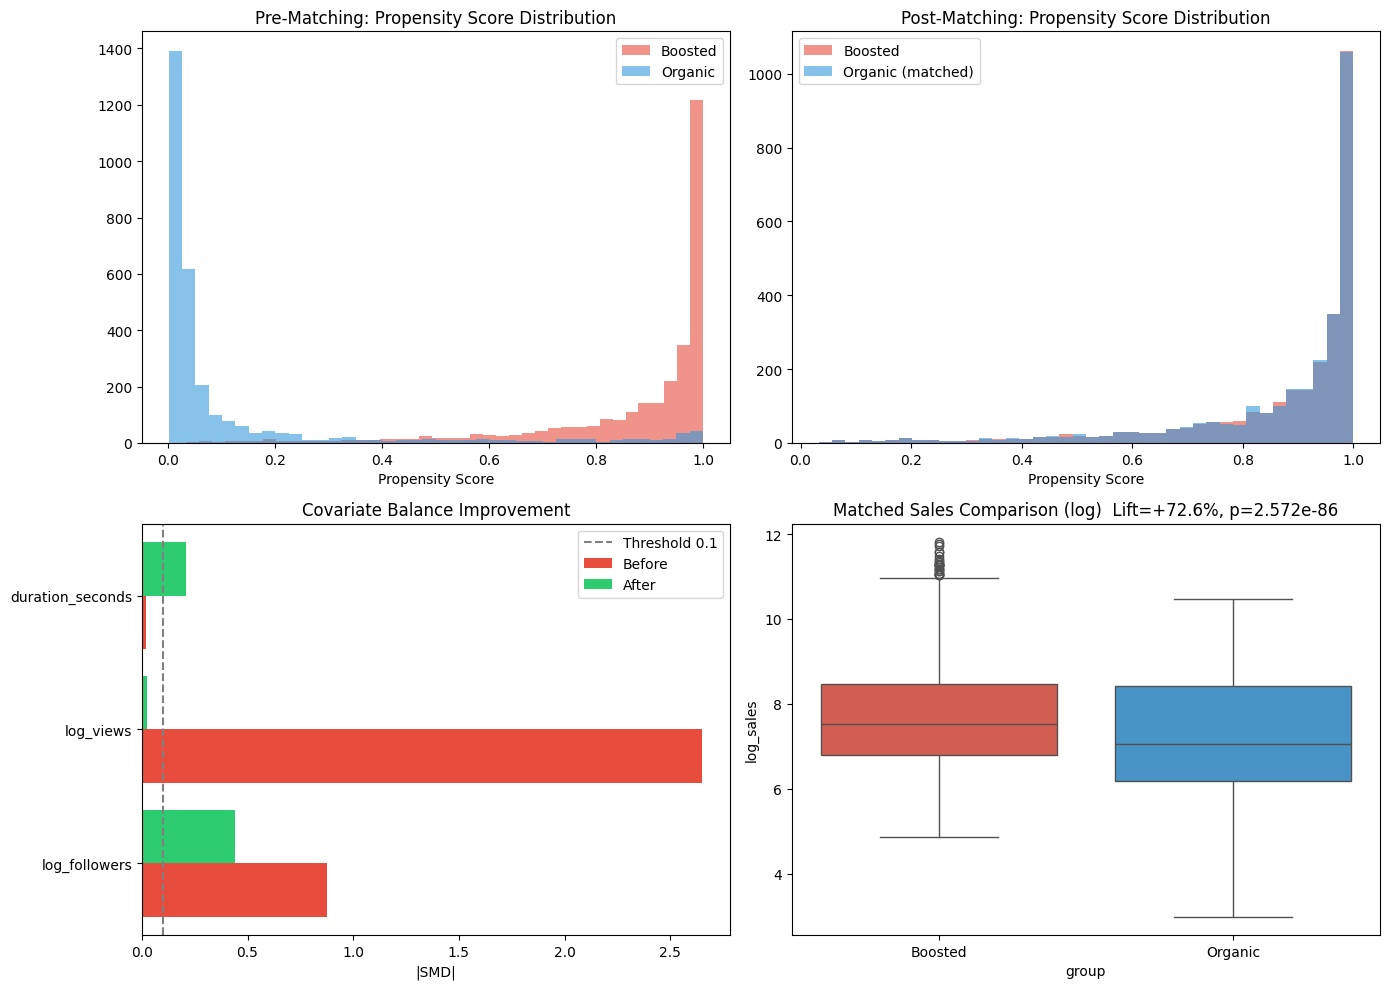


Done. Figure saved to psm_analysis.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy import stats

np.random.seed(42)

boosted = pd.read_csv('/content/drive/MyDrive/DSO 559 Python/fastmoss data/fastmoss data - cleaned/Medicube/medicube_videos_boosted_cleaned.csv')
organic = pd.read_csv('/content/drive/MyDrive/DSO 559 Python/fastmoss data/fastmoss data - cleaned/Medicube/medicube_videos_organic_cleaned.csv')

df = pd.concat([boosted, organic], ignore_index=True)
df['treated'] = (df['is_boosted'] == 'Yes').astype(int)  # 1=boosted, 0=organic

print(f"Total: {len(df)} videos "
      f"(boosted={df['treated'].sum()}, organic={(1-df['treated']).sum()})\n")

# Feature preparation
# Confounders (matching covariates): followers, views, duration
# Outcome: 90-day store sales revenue
cols_needed = ['followers', 'views', 'duration_seconds',
               'store_sales_revenue_90d', 'store_sales_volume_90d', 'treated']
df = df[cols_needed].dropna()

# Log-transform heavy-tailed variables (followers, views, revenue are power-law)
df['log_followers'] = np.log1p(df['followers'])
df['log_views']     = np.log1p(df['views'])
df['log_revenue']   = np.log1p(df['store_sales_revenue_90d'])

covariates  = ['log_followers', 'log_views', 'duration_seconds']
outcome_raw = 'store_sales_revenue_90d'   # absolute $, for business read
outcome_log = 'log_revenue'               # log-scale, more robust for tests

# Pre-matching balance check
def balance_check(data, covs, treat_col='treated'):
    """Compute Standardized Mean Difference. |SMD| < 0.1 = balanced."""
    rows = []
    for c in covs:
        t = data.loc[data[treat_col] == 1, c]
        u = data.loc[data[treat_col] == 0, c]
        pooled_sd = np.sqrt((t.var() + u.var()) / 2)
        smd = (t.mean() - u.mean()) / pooled_sd if pooled_sd > 0 else 0
        rows.append({
            'variable': c,
            'mean_boosted': t.mean(),
            'mean_organic': u.mean(),
            'smd': smd
        })
    return pd.DataFrame(rows)

print("=" * 65)
print("[BEFORE MATCHING] Covariate balance (|SMD|>0.1 = imbalanced)")
print("=" * 65)
smd_before = balance_check(df, covariates)
print(smd_before.round(4).to_string(index=False))
print()

# Estimate propensity score
X = df[covariates].values
y = df['treated'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X_scaled, y)
df['pscore'] = ps_model.predict_proba(X_scaled)[:, 1]

print("=" * 65)
print("Propensity score distribution by group")
print("=" * 65)
print(df.groupby('treated')['pscore'].describe().round(4))
print()

# Common support region
# Keep only samples in the overlapping pscore range
ps_min = max(df[df.treated == 1]['pscore'].min(),
             df[df.treated == 0]['pscore'].min())
ps_max = min(df[df.treated == 1]['pscore'].max(),
             df[df.treated == 0]['pscore'].max())
df_cs = df[(df['pscore'] >= ps_min) & (df['pscore'] <= ps_max)].copy()
print(f"Common support: [{ps_min:.4f}, {ps_max:.4f}] -> "
      f"kept {len(df_cs)}/{len(df)} rows\n")

# Nearest neighbor matching (1:1, with caliper)
treated_df   = df_cs[df_cs['treated'] == 1].copy().reset_index(drop=True)
control_pool = df_cs[df_cs['treated'] == 0].copy().reset_index(drop=True)

# Caliper = 0.2 * SD(logit(pscore))
logit_ps = np.log(df_cs['pscore'] / (1 - df_cs['pscore']))
caliper = 0.2 * logit_ps.std()
print(f"Caliper = {caliper:.4f} (0.2 x SD of logit propensity score)\n")

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_pool[['pscore']].values)
distances, indices = nn.kneighbors(treated_df[['pscore']].values)

# Convert to logit distance and filter by caliper
treated_logit = np.log(treated_df['pscore'] / (1 - treated_df['pscore'])).values
control_logit = np.log(control_pool['pscore'] / (1 - control_pool['pscore'])).values
logit_dist = np.abs(treated_logit - control_logit[indices.flatten()])

keep_mask = logit_dist <= caliper
matched_treated = treated_df[keep_mask].reset_index(drop=True)
matched_control = control_pool.iloc[indices.flatten()[keep_mask]].reset_index(drop=True)

matched = pd.concat([matched_treated, matched_control], ignore_index=True)
print(f"Successful matches: {len(matched_treated)} pairs "
      f"(dropped {(~keep_mask).sum()} treated units without good match)\n")

# Post-matching balance check
print("=" * 65)
print("[AFTER MATCHING] Covariate balance")
print("=" * 65)
smd_after = balance_check(matched, covariates)
print(smd_after.round(4).to_string(index=False))
print()

# Side-by-side SMD comparison
compare = smd_before[['variable', 'smd']].rename(columns={'smd': 'smd_before'}).merge(
    smd_after[['variable', 'smd']].rename(columns={'smd': 'smd_after'}),
    on='variable'
)
compare['improvement'] = compare['smd_before'].abs() - compare['smd_after'].abs()
print("Balance improvement:")
print(compare.round(4).to_string(index=False))
print()

# Estimate ATT (Average Treatment effect on Treated)
t_sales     = matched_treated[outcome_raw].values
c_sales     = matched_control[outcome_raw].values
t_log_sales = matched_treated[outcome_log].values
c_log_sales = matched_control[outcome_log].values

att_abs = t_sales.mean() - c_sales.mean()
att_log = t_log_sales.mean() - c_log_sales.mean()
lift_pct = (np.exp(att_log) - 1) * 100   # log diff -> % lift

# Paired t-test (matching produces paired structure)
t_stat_raw, p_raw = stats.ttest_rel(t_sales, c_sales)
t_stat_log, p_log = stats.ttest_rel(t_log_sales, c_log_sales)
# Non-parametric check (robust to extreme values)
w_stat, p_wilcox = stats.wilcoxon(t_sales, c_sales)

# Bootstrap 95% CI
n_boot = 1000
diffs = t_sales - c_sales
boot_means = [np.random.choice(diffs, size=len(diffs), replace=True).mean()
              for _ in range(n_boot)]
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

print("=" * 65)
print("ATT Estimation Results (true incremental effect of boosting)")
print("=" * 65)
print(f"Boosted  avg 90d sales: ${t_sales.mean():>12,.2f}")
print(f"Organic  avg 90d sales: ${c_sales.mean():>12,.2f}")
print(f"ATT (absolute diff): ${att_abs:,.2f}")
print(f"95% Bootstrap CI: [${ci_low:,.2f}, ${ci_high:,.2f}]")
print(f"Log ATT: {att_log:.4f}  ->  boosting lifts sales by ~{lift_pct:.1f}%")
print(f"\nPaired t-test (raw):      t={t_stat_raw:.3f}, p={p_raw:.4e}")
print(f"Paired t-test (log):      t={t_stat_log:.3f}, p={p_log:.4e}")
print(f"Wilcoxon signed-rank:     W={w_stat:.0f}, p={p_wilcox:.4e}")

verdict = "SIGNIFICANT (p<0.05)" if p_log < 0.05 else "NOT SIGNIFICANT"
print(f"\nConclusion: {verdict}")
print("=" * 65)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Pre-matching pscore distribution
axes[0, 0].hist(df[df.treated == 1]['pscore'], bins=40, alpha=0.6,
                label='Boosted', color='#E74C3C')
axes[0, 0].hist(df[df.treated == 0]['pscore'], bins=40, alpha=0.6,
                label='Organic', color='#3498DB')
axes[0, 0].set_title('Pre-Matching: Propensity Score Distribution')
axes[0, 0].set_xlabel('Propensity Score')
axes[0, 0].legend()

# (b) Post-matching pscore distribution
axes[0, 1].hist(matched_treated['pscore'], bins=40, alpha=0.6,
                label='Boosted', color='#E74C3C')
axes[0, 1].hist(matched_control['pscore'], bins=40, alpha=0.6,
                label='Organic (matched)', color='#3498DB')
axes[0, 1].set_title('Post-Matching: Propensity Score Distribution')
axes[0, 1].set_xlabel('Propensity Score')
axes[0, 1].legend()

# (c) SMD comparison
y_pos = np.arange(len(compare))
axes[1, 0].barh(y_pos - 0.2, compare['smd_before'].abs(), 0.4,
                label='Before', color='#E74C3C')
axes[1, 0].barh(y_pos + 0.2, compare['smd_after'].abs(), 0.4,
                label='After', color='#2ECC71')
axes[1, 0].axvline(0.1, color='gray', linestyle='--', label='Threshold 0.1')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(compare['variable'])
axes[1, 0].set_xlabel('|SMD|')
axes[1, 0].set_title('Covariate Balance Improvement')
axes[1, 0].legend()

# (d) Sales comparison (log scale to handle outliers)
plot_df = pd.DataFrame({
    'group': ['Boosted'] * len(t_log_sales) + ['Organic'] * len(c_log_sales),
    'log_sales': np.concatenate([t_log_sales, c_log_sales])
})
sns.boxplot(data=plot_df, x='group', y='log_sales', ax=axes[1, 1],
            palette=['#E74C3C', '#3498DB'])
axes[1, 1].set_title(f'Matched Sales Comparison (log)  '
                     f'Lift={lift_pct:+.1f}%, p={p_log:.3e}')

plt.tight_layout()
plt.savefig('psm_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nDone. Figure saved to psm_analysis.png")

Part 2.2 Robustness Check: Sensitivity Analysis for PSM
Goal: Test whether the ~72.6% ATT estimate is robust to different
      matching specifications, particularly removing log_views
      (which may be a 'bad control' - partially caused by treatment).

Three specifications:
  Model A: log_followers + log_views + duration_seconds (original)
  Model B: log_followers + duration_seconds (drop log_views - preferred)
  Model C: log_followers only (strictest - followers are pre-treatment)

Loaded 6000 videos (boosted=3000, organic=3000)

>>> Running Model A: followers + views + duration (original) ...
    Matched pairs: 2844, max |SMD| after: 0.440, ATT lift: +72.6%

>>> Running Model B: followers + duration (drop views) ...
    Matched pairs: 2992, max |SMD| after: 0.041, ATT lift: +2048.6%

>>> Running Model C: followers only (strictest - pre-treatment) ...
    Matched pairs: 2986, max |SMD| after: 0.000, ATT lift: +2124.1%

ROBUSTNESS CHECK: Side-by-Side Comparison of Three Matching Specifications
  Model                   Covariates  N pairs Max |SMD| Boosted $ Organic $  ATT $            95% CI   Lift %  p-value Significant
Model A followers + views + duration     2844     0.440    $5,281    $4,129 $1,153    [$744, $1,557]   +72.6% 2.57e-86           ✓
Model B         followers + duration     2992     0.041    $9,856      $592 $9,265 [$7,873, $10,722] +2048.6% 0.00e+00           ✓
Model C                    followers     2986     0.000    $9,871      $651 $9,220 [$7

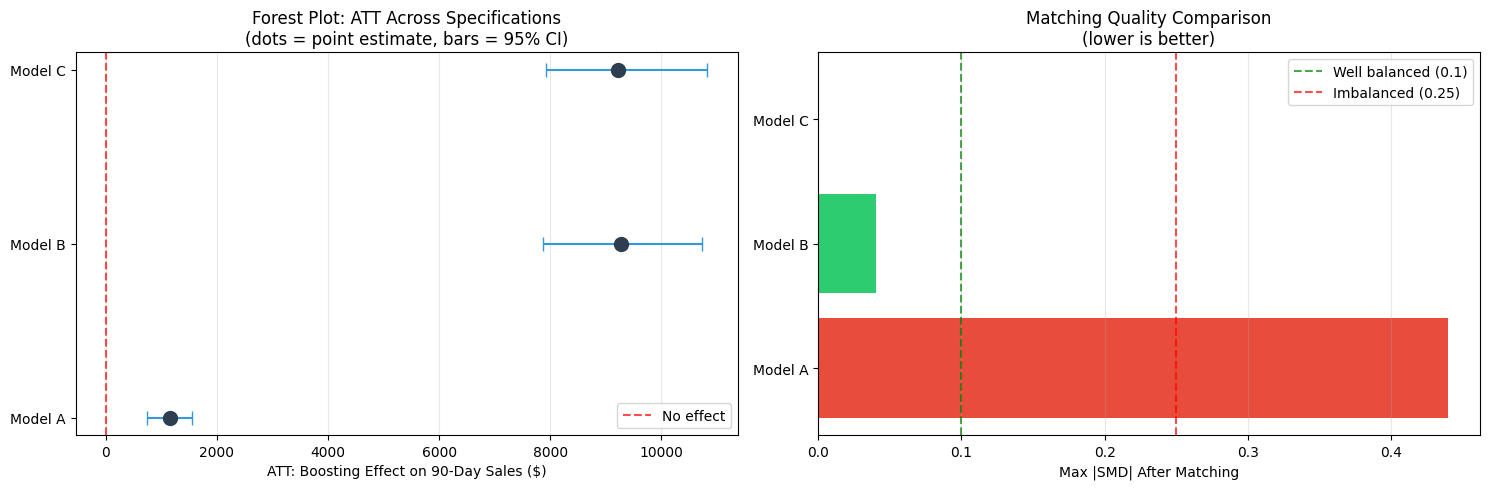


Done. Figure saved to psm_robustness_check.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy import stats

np.random.seed(42)

# Load data (same as before)
boosted = pd.read_csv('/content/drive/MyDrive/DSO 559 Python/fastmoss data/fastmoss data - cleaned/Medicube/medicube_videos_boosted_cleaned.csv')
organic = pd.read_csv('/content/drive/MyDrive/DSO 559 Python/fastmoss data/fastmoss data - cleaned/Medicube/medicube_videos_organic_cleaned.csv')

df = pd.concat([boosted, organic], ignore_index=True)
df['treated'] = (df['is_boosted'] == 'Yes').astype(int)

cols_needed = ['followers', 'views', 'duration_seconds',
               'store_sales_revenue_90d', 'treated']
df = df[cols_needed].dropna()
df['log_followers'] = np.log1p(df['followers'])
df['log_views']     = np.log1p(df['views'])
df['log_revenue']   = np.log1p(df['store_sales_revenue_90d'])

outcome_raw = 'store_sales_revenue_90d'
outcome_log = 'log_revenue'

print(f"Loaded {len(df)} videos "
      f"(boosted={df['treated'].sum()}, organic={(1-df['treated']).sum()})\n")

# Core PSM function (reusable)
def run_psm(data, covariates, label):
    """Run full PSM pipeline and return diagnostics + ATT estimates."""
    X = data[covariates].values
    y = data['treated'].values

    # Estimate propensity score
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    ps_model = LogisticRegression(max_iter=1000)
    ps_model.fit(X_scaled, y)
    data = data.copy()
    data['pscore'] = ps_model.predict_proba(X_scaled)[:, 1]

    # Common support
    ps_min = max(data[data.treated==1]['pscore'].min(),
                 data[data.treated==0]['pscore'].min())
    ps_max = min(data[data.treated==1]['pscore'].max(),
                 data[data.treated==0]['pscore'].max())
    data_cs = data[(data['pscore'] >= ps_min) & (data['pscore'] <= ps_max)].copy()

    # Caliper matching
    treated_df   = data_cs[data_cs['treated'] == 1].reset_index(drop=True)
    control_pool = data_cs[data_cs['treated'] == 0].reset_index(drop=True)

    logit_ps = np.log(data_cs['pscore'] / (1 - data_cs['pscore']))
    caliper = 0.2 * logit_ps.std()

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control_pool[['pscore']].values)
    distances, indices = nn.kneighbors(treated_df[['pscore']].values)

    t_logit = np.log(treated_df['pscore'] / (1 - treated_df['pscore'])).values
    c_logit = np.log(control_pool['pscore'] / (1 - control_pool['pscore'])).values
    logit_dist = np.abs(t_logit - c_logit[indices.flatten()])
    keep = logit_dist <= caliper

    matched_t = treated_df[keep].reset_index(drop=True)
    matched_c = control_pool.iloc[indices.flatten()[keep]].reset_index(drop=True)

    # Balance check after matching
    balance = []
    for c in covariates:
        t_mean, c_mean = matched_t[c].mean(), matched_c[c].mean()
        pooled_sd = np.sqrt((matched_t[c].var() + matched_c[c].var()) / 2)
        smd = (t_mean - c_mean) / pooled_sd if pooled_sd > 0 else 0
        balance.append({'variable': c, 'smd_after': smd})
    balance_df = pd.DataFrame(balance)

    # ATT estimates
    t_sales = matched_t[outcome_raw].values
    c_sales = matched_c[outcome_raw].values
    t_log   = matched_t[outcome_log].values
    c_log   = matched_c[outcome_log].values

    att_abs  = t_sales.mean() - c_sales.mean()
    att_log  = t_log.mean() - c_log.mean()
    lift_pct = (np.exp(att_log) - 1) * 100

    _, p_log = stats.ttest_rel(t_log, c_log)

    # Bootstrap CI
    diffs = t_sales - c_sales
    boot = [np.random.choice(diffs, size=len(diffs), replace=True).mean()
            for _ in range(1000)]
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    # Max absolute SMD after matching (quality score)
    max_smd = balance_df['smd_after'].abs().max()

    return {
        'model': label,
        'covariates': covariates,
        'n_matched': len(matched_t),
        'n_dropped': (~keep).sum(),
        'max_smd_after': max_smd,
        'balance_detail': balance_df,
        'boosted_mean': t_sales.mean(),
        'organic_mean': c_sales.mean(),
        'att_abs': att_abs,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'att_log': att_log,
        'lift_pct': lift_pct,
        'p_value': p_log
    }

# Run three specifications
specs = [
    ('Model A: followers + views + duration (original)',
     ['log_followers', 'log_views', 'duration_seconds']),
    ('Model B: followers + duration (drop views)',
     ['log_followers', 'duration_seconds']),
    ('Model C: followers only (strictest - pre-treatment)',
     ['log_followers'])
]

results = []
for label, covs in specs:
    print(f">>> Running {label} ...")
    res = run_psm(df, covs, label)
    results.append(res)
    print(f"    Matched pairs: {res['n_matched']}, "
          f"max |SMD| after: {res['max_smd_after']:.3f}, "
          f"ATT lift: {res['lift_pct']:+.1f}%\n")

# Side-by-side comparison table
print("=" * 90)
print("ROBUSTNESS CHECK: Side-by-Side Comparison of Three Matching Specifications")
print("=" * 90)

summary = pd.DataFrame([{
    'Model': r['model'].split(':')[0],
    'Covariates': ' + '.join([c.replace('log_','').replace('_seconds','') for c in r['covariates']]),
    'N pairs': r['n_matched'],
    'Max |SMD|': f"{r['max_smd_after']:.3f}",
    'Boosted $': f"${r['boosted_mean']:,.0f}",
    'Organic $': f"${r['organic_mean']:,.0f}",
    'ATT $': f"${r['att_abs']:,.0f}",
    '95% CI': f"[${r['ci_low']:,.0f}, ${r['ci_high']:,.0f}]",
    'Lift %': f"{r['lift_pct']:+.1f}%",
    'p-value': f"{r['p_value']:.2e}",
    'Significant': '✓' if r['p_value'] < 0.05 else '✗'
} for r in results])

print(summary.to_string(index=False))
print()

# Per-covariate balance detail for each model
print("=" * 90)
print("Per-Covariate |SMD| After Matching (< 0.1 = well balanced)")
print("=" * 90)
for r in results:
    print(f"\n[{r['model']}]")
    detail = r['balance_detail'].copy()
    detail['abs_smd'] = detail['smd_after'].abs()
    detail['balanced'] = detail['abs_smd'].apply(
        lambda x: '✓ balanced' if x < 0.1 else ('~ok' if x < 0.25 else '✗ imbalanced'))
    print(detail.round(4).to_string(index=False))

# Interpretation
print("\n" + "=" * 90)
print("INTERPRETATION")
print("=" * 90)

lifts = [r['lift_pct'] for r in results]
sigs  = [r['p_value'] < 0.05 for r in results]
max_smds = [r['max_smd_after'] for r in results]

print(f"\nLift range across three models: {min(lifts):+.1f}%  to  {max(lifts):+.1f}%")
print(f"All three significant (p<0.05): {all(sigs)}")
print(f"Best-balanced model (lowest max |SMD|): "
      f"{results[np.argmin(max_smds)]['model'].split(':')[0]} "
      f"(max |SMD|={min(max_smds):.3f})")

# Decision logic
if all(sigs) and max(lifts) - min(lifts) < 20:
    verdict = ("ROBUST: Effect direction and magnitude are consistent across "
               "specifications. The conclusion that boosting lifts sales is reliable.")
elif all(sigs) and max(lifts) - min(lifts) >= 20:
    verdict = ("DIRECTION ROBUST, MAGNITUDE UNCERTAIN: All models show significant "
               "positive effect, but the size varies substantially (>20pp spread). "
               "Report the range, not a single number. Model B is likely most credible.")
elif not all(sigs):
    verdict = ("FRAGILE: Effect disappears in at least one specification. The original "
               "72.6% lift was likely driven by 'bad control' (using views, which is "
               "partially caused by boosting itself). Treat with caution.")

print(f"\nVerdict: {verdict}")
print("=" * 90)

# Visualization: forest plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Forest plot of ATT estimates
model_names = [r['model'].split(':')[0] for r in results]
att_values  = [r['att_abs'] for r in results]
ci_lows     = [r['ci_low'] for r in results]
ci_highs    = [r['ci_high'] for r in results]
y_pos = np.arange(len(results))

axes[0].errorbar(att_values, y_pos,
                 xerr=[[a-l for a,l in zip(att_values, ci_lows)],
                       [h-a for a,h in zip(att_values, ci_highs)]],
                 fmt='o', capsize=5, markersize=10, color='#2C3E50', ecolor='#3498DB')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='No effect')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(model_names)
axes[0].set_xlabel('ATT: Boosting Effect on 90-Day Sales ($)')
axes[0].set_title('Forest Plot: ATT Across Specifications\n(dots = point estimate, bars = 95% CI)')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# (b) Max |SMD| comparison (matching quality)
max_smd_values = [r['max_smd_after'] for r in results]
colors = ['#2ECC71' if s < 0.1 else '#F39C12' if s < 0.25 else '#E74C3C'
          for s in max_smd_values]
axes[1].barh(y_pos, max_smd_values, color=colors)
axes[1].axvline(0.1, color='green', linestyle='--', alpha=0.7, label='Well balanced (0.1)')
axes[1].axvline(0.25, color='red', linestyle='--', alpha=0.7, label='Imbalanced (0.25)')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(model_names)
axes[1].set_xlabel('Max |SMD| After Matching')
axes[1].set_title('Matching Quality Comparison\n(lower is better)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('psm_robustness_check.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nDone. Figure saved to psm_robustness_check.png")

Part 2.3: Video Content Features -> Store Sales Revenue (Multiple Regression)
Goal: Identify which factors actually drive Medicube's 90-day store sales.
Variables: views, followers, duration, is_boosted, creator_category
           -> store_sales_revenue_90d
Method: OLS with log transformation + HC3 robust standard errors.

Sample size for 2.3: 6000

VIF Check
           feature     VIF
0        log_views  31.064
1    log_followers  31.473
2     log_duration  18.849
3  is_boosted_flag   4.192

OLS Regression Results
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     3002.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        06:51:55   Log-Likelihood:                -7151.8
No. Observations:                6000   AIC:                         1.433e+04
Df Residuals:                    5985   BIC:                         1.443e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
              

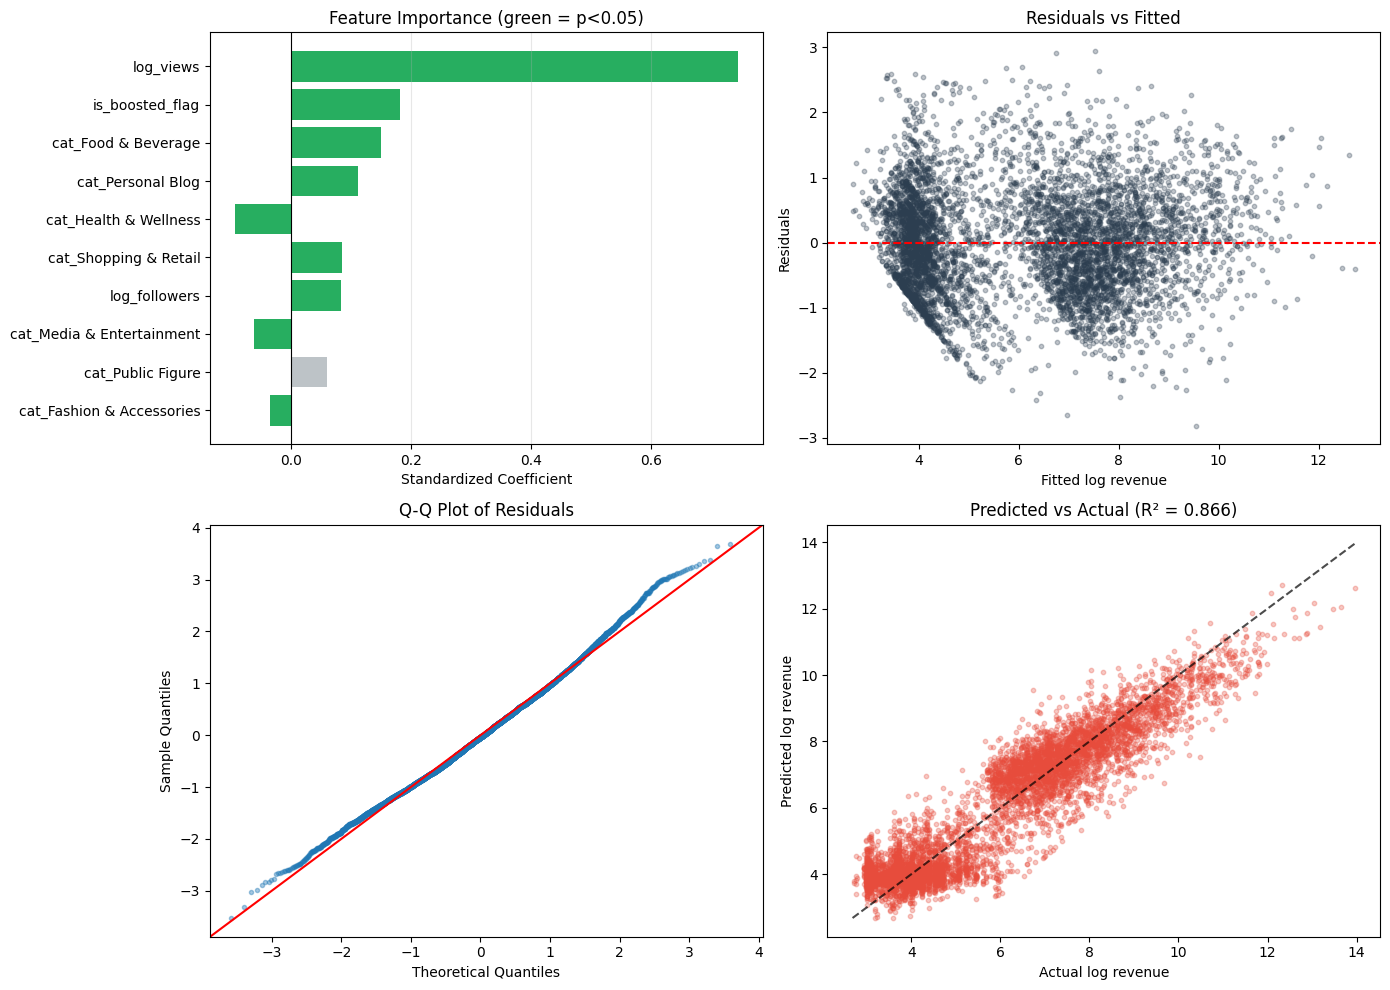


Model fit: R² = 0.8665, Adj R² = 0.8662, N = 6000
Done. Figure saved to sales_regression_diagnostics.png


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Build fresh dataframe for 2.3
df = pd.concat([boosted, organic], ignore_index=True)
df['is_boosted_flag'] = (df['is_boosted'] == 'Yes').astype(int)

cols_needed = ['followers', 'views', 'duration_seconds', 'is_boosted_flag',
               'creator_category', 'store_sales_revenue_90d']
df = df[cols_needed].dropna()
df = df[df['store_sales_revenue_90d'] > 0].copy()

df['log_views']     = np.log1p(df['views'])
df['log_followers'] = np.log1p(df['followers'])
df['log_duration']  = np.log1p(df['duration_seconds'])
df['log_revenue']   = np.log1p(df['store_sales_revenue_90d'])

print(f"Sample size for 2.3: {len(df)}\n")

# Group rare creator categories
cat_counts = df['creator_category'].value_counts()
top_cats = cat_counts[cat_counts >= 50].index.tolist()
df['creator_cat_grouped'] = df['creator_category'].where(
    df['creator_category'].isin(top_cats), 'Other'
)
cat_dummies = pd.get_dummies(df['creator_cat_grouped'],
                             prefix='cat', drop_first=True, dtype=float)

# Design matrix
numeric_features = ['log_views', 'log_followers', 'log_duration', 'is_boosted_flag']
X = pd.concat([df[numeric_features].reset_index(drop=True),
               cat_dummies.reset_index(drop=True)], axis=1)
y = df['log_revenue'].reset_index(drop=True)

# VIF check
print("=" * 70)
print("VIF Check")
print("=" * 70)
X_num = df[numeric_features]
vif_df = pd.DataFrame({
    'feature': X_num.columns,
    'VIF': [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
})
print(vif_df.round(3))
print()

# OLS with HC3 robust SEs
model = sm.OLS(y, sm.add_constant(X)).fit(cov_type='HC3')
print("=" * 70)
print("OLS Regression Results")
print("=" * 70)
print(model.summary())

# Standardized coefficients
X_std_num = (X[numeric_features] - X[numeric_features].mean()) / X[numeric_features].std()
X_std = pd.concat([X_std_num.reset_index(drop=True),
                   cat_dummies.reset_index(drop=True)], axis=1)
y_std = (y - y.mean()) / y.std()
model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit(cov_type='HC3')

std_table = pd.DataFrame({
    'feature': X.columns,
    'std_beta': model_std.params[1:].values,
    'p_value': model_std.pvalues[1:].values
})
std_table['abs_beta'] = std_table['std_beta'].abs()
std_table['sig'] = std_table['p_value'].apply(
    lambda p: '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else '')
std_table = std_table.sort_values('abs_beta', ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("Feature Importance (Standardized Coefficients)")
print("=" * 70)
print(std_table[['feature', 'std_beta', 'p_value', 'sig']].round(4).to_string(index=False))

# Business interpretation
print("\n" + "=" * 70)
print("Business Interpretation")
print("=" * 70)
for feat in X.columns:
    coef = model.params[feat]
    pval = model.pvalues[feat]
    if pval >= 0.05:
        continue  # skip non-significant for brevity
    if feat.startswith('log_'):
        print(f"  {feat:25s}: 1% increase in {feat[4:]} -> {coef:+.3f}% in revenue  (p={pval:.2e})")
    elif feat == 'is_boosted_flag':
        pct = (np.exp(coef) - 1) * 100
        print(f"  {feat:25s}: boosted vs organic -> {pct:+.1f}% revenue  (p={pval:.2e})")
    else:
        pct = (np.exp(coef) - 1) * 100
        print(f"  {feat:25s}: {pct:+.1f}% vs reference category  (p={pval:.2e})")

# Diagnostic plots
fitted = model.fittedvalues
resid = model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_plot = std_table.head(10).iloc[::-1]
colors = ['#27AE60' if p < 0.05 else '#BDC3C7' for p in top_plot['p_value']]
axes[0, 0].barh(top_plot['feature'], top_plot['std_beta'], color=colors)
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_xlabel('Standardized Coefficient')
axes[0, 0].set_title('Feature Importance (green = p<0.05)')
axes[0, 0].grid(axis='x', alpha=0.3)

axes[0, 1].scatter(fitted, resid, alpha=0.3, s=10, color='#2C3E50')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Fitted log revenue')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Fitted')

sm.qqplot(resid, line='45', fit=True, ax=axes[1, 0], markersize=3, alpha=0.4)
axes[1, 0].set_title('Q-Q Plot of Residuals')

axes[1, 1].scatter(y, fitted, alpha=0.3, s=10, color='#E74C3C')
lims = [min(y.min(), fitted.min()), max(y.max(), fitted.max())]
axes[1, 1].plot(lims, lims, 'k--', alpha=0.7)
axes[1, 1].set_xlabel('Actual log revenue')
axes[1, 1].set_ylabel('Predicted log revenue')
axes[1, 1].set_title(f'Predicted vs Actual (R² = {model.rsquared:.3f})')

plt.tight_layout()
plt.savefig('sales_regression_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nModel fit: R² = {model.rsquared:.4f}, Adj R² = {model.rsquared_adj:.4f}, "
      f"N = {int(model.nobs)}")
print("Done. Figure saved to sales_regression_diagnostics.png")

Part 2.4: Influencer Tier Efficiency Analysis
Goal: Which influencer tier (nano/micro/macro/mega) gives Medicube the
      best bang for the buck?
Method:
  (1) Bin by follower count using standard industry thresholds
  (2) ANOVA + post-hoc Tukey HSD: does video_gpm differ across tiers?
  (3) Regression: followers -> video_gpm (continuous relationship)
Key metric: video_gpm = sales revenue per 1,000 video views (conversion efficiency)

Raw influencer data: 3000 rows

After GPM parsing:
  USD-denominated, parseable: 2994
  Dropped (non-USD or bad format): 6

Dropped 141 rows with zero GPM (creators with no video-driven sales)
Final sample: 2852 creators

Descriptive statistics by tier
                  n_creators  mean_gpm  median_gpm  std_gpm  avg_followers  \
tier                                                                         
Nano  (<10K)             761     35.17       29.69    31.88         6039.0   
Micro (10K-100K)        1392     32.48       27.23    26.72        33418.0   
Macro (100K-1M)          604     38.21       30.21    38.08       309810.0   
Mega  (>1M)               95     59.76       38.96    83.45      2133160.0   

                  total_revenue_90d  
tier                                 
Nano  (<10K)              4826666.0  
Micro (10K-100K)         27290683.0  
Macro (100K-1M)          17814231.0  
Mega  (>1M)               2167258.0  

Skewness of video_gpm within each tier (|skew|>1 

/tmp/ipykernel_2079/1247843500.py:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tier', y='video_gpm_usd', ax=axes[0, 0],


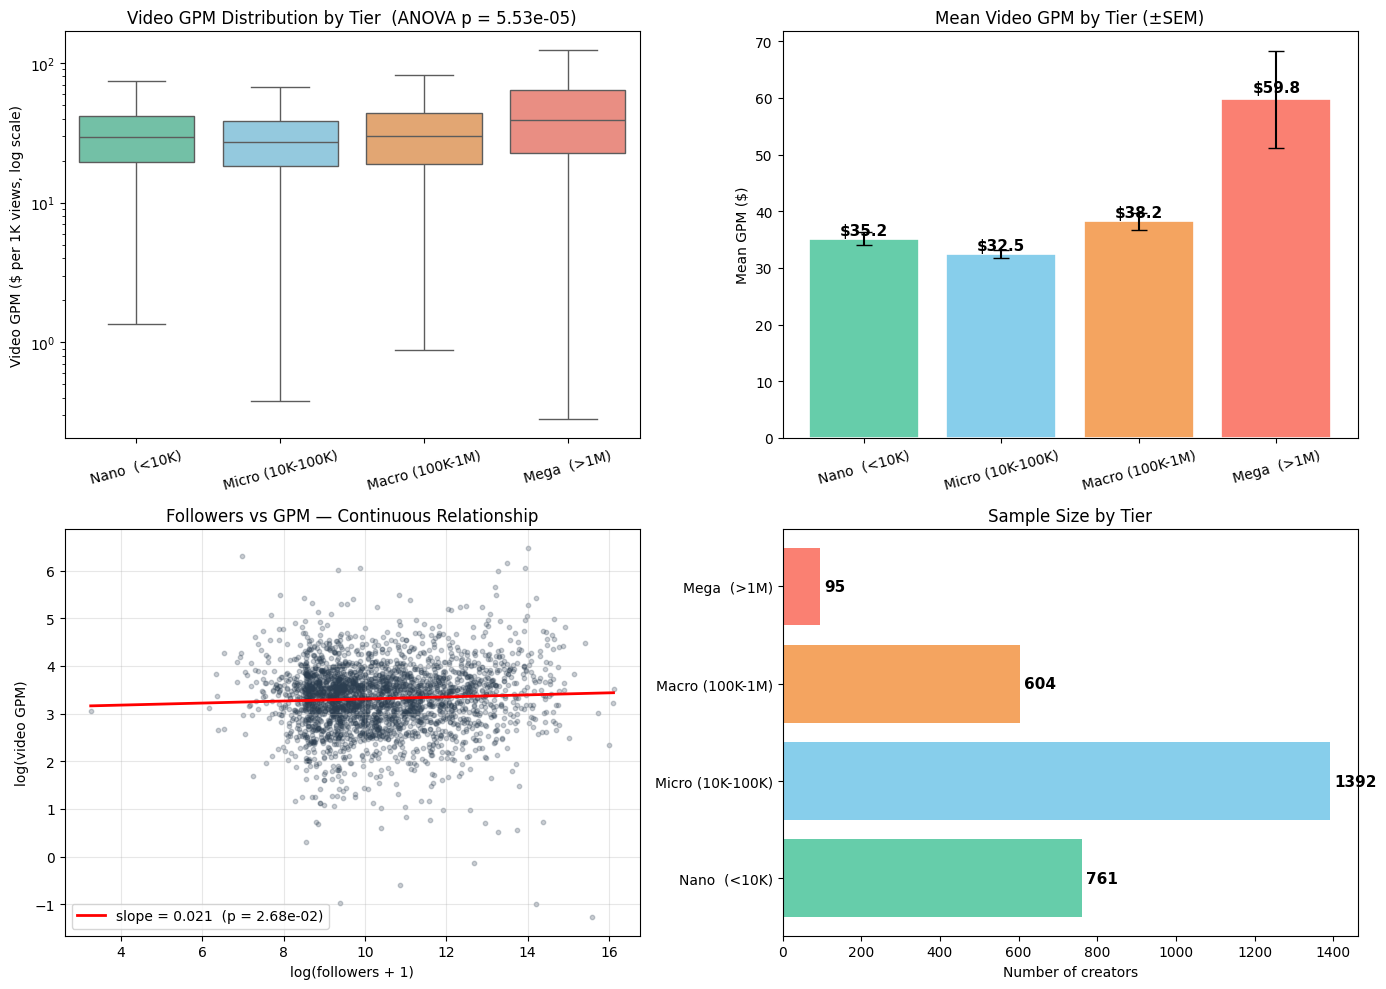


Done. Figure saved to influencer_tier_analysis.png


In [ ]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)

# Load data
infl = pd.read_csv('/content/drive/MyDrive/DSO 559 Python/fastmoss data/fastmoss data - cleaned/Medicube/medicube_influencers_cleaned.csv')
print(f"Raw influencer data: {infl.shape[0]} rows\n")

# Parse video_gpm string range -> numeric midpoint
def parse_gpm(s):
    """Parse strings like '$31.77-$33.31' into midpoint float.
    Returns NaN for non-USD or unparseable values."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    # Only keep USD rows (reject €, MX$, etc.)
    if not s.startswith('$'):
        return np.nan
    # Extract all floats in the string
    nums = re.findall(r'[\d.]+', s)
    if len(nums) < 2:
        return np.nan
    try:
        low, high = float(nums[0]), float(nums[1])
        return (low + high) / 2
    except ValueError:
        return np.nan

infl['video_gpm_usd'] = infl['video_gpm'].apply(parse_gpm)

print(f"After GPM parsing:")
print(f"  USD-denominated, parseable: {infl['video_gpm_usd'].notna().sum()}")
print(f"  Dropped (non-USD or bad format): {infl['video_gpm_usd'].isna().sum()}")
print()

# Clean + filter
df = infl.dropna(subset=['video_gpm_usd']).copy()

# Drop videos with zero GPM (no video sales — these tell us nothing about efficiency)
zero_gpm = (df['video_gpm_usd'] == 0).sum()
df = df[df['video_gpm_usd'] > 0].copy()
print(f"Dropped {zero_gpm} rows with zero GPM (creators with no video-driven sales)")

# Drop followers = 0 rows (data quality)
df = df[df['followers'] > 0].copy()
print(f"Final sample: {len(df)} creators\n")

# Bin influencers into tiers (industry standard)
def assign_tier(f):
    if f < 10_000:        return 'Nano  (<10K)'
    elif f < 100_000:     return 'Micro (10K-100K)'
    elif f < 1_000_000:   return 'Macro (100K-1M)'
    else:                 return 'Mega  (>1M)'

df['tier'] = df['followers'].apply(assign_tier)
# Make tier an ordered categorical for plotting + grouping
tier_order = ['Nano  (<10K)', 'Micro (10K-100K)', 'Macro (100K-1M)', 'Mega  (>1M)']
df['tier'] = pd.Categorical(df['tier'], categories=tier_order, ordered=True)

# Descriptive stats by tier
print("=" * 75)
print("Descriptive statistics by tier")
print("=" * 75)
desc = df.groupby('tier', observed=True)['video_gpm_usd'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)
desc.columns = ['n_creators', 'mean_gpm', 'median_gpm', 'std_gpm']
# Add follower stats
desc['avg_followers'] = df.groupby('tier', observed=True)['followers'].mean().round(0)
desc['total_revenue_90d'] = df.groupby('tier', observed=True)['sales_revenue_90d'].sum().round(0)
print(desc)
print()

# Assumption check: is GPM normally distributed within tiers?
# If strongly skewed, prefer log-GPM for ANOVA
print("=" * 75)
print("Skewness of video_gpm within each tier (|skew|>1 = highly skewed)")
print("=" * 75)
skew_by_tier = df.groupby('tier', observed=True)['video_gpm_usd'].apply(
    lambda x: stats.skew(x)
).round(2)
print(skew_by_tier)

# Use log GPM for more normal distribution
df['log_gpm'] = np.log(df['video_gpm_usd'])
print("\nAfter log transform, skewness:")
print(df.groupby('tier', observed=True)['log_gpm'].apply(
    lambda x: stats.skew(x)
).round(2))
print()

# One-way ANOVA on log_gpm
groups = [df[df['tier']==t]['log_gpm'].values for t in tier_order]
f_stat, p_anova = stats.f_oneway(*groups)
# Also run non-parametric Kruskal-Wallis as a robustness check
h_stat, p_kw = stats.kruskal(*groups)

print("=" * 75)
print("ANOVA: does mean GPM differ across tiers?")
print("=" * 75)
print(f"One-way ANOVA (on log_gpm):   F = {f_stat:.3f},  p = {p_anova:.4e}")
print(f"Kruskal-Wallis (non-param):   H = {h_stat:.3f},  p = {p_kw:.4e}")
anova_verdict = ("✓ Significant differences between tiers (p<0.05)"
                 if p_anova < 0.05 else "✗ No significant differences")
print(f"Verdict: {anova_verdict}\n")

# Post-hoc Tukey HSD: which tiers differ from which?
print("=" * 75)
print("Tukey HSD post-hoc: pairwise tier comparisons")
print("=" * 75)
tukey = pairwise_tukeyhsd(df['log_gpm'].values, df['tier'].values, alpha=0.05)
print(tukey.summary())
print()

# Regression: continuous effect of followers on GPM
# log-log to get elasticity: "1% more followers -> X% change in GPM"
df['log_followers'] = np.log1p(df['followers'])

X = sm.add_constant(df[['log_followers']])
y = df['log_gpm']
model = sm.OLS(y, X).fit(cov_type='HC3')

print("=" * 75)
print("Regression: log(followers) -> log(video_gpm)")
print("=" * 75)
print(model.summary())

slope = model.params['log_followers']
slope_p = model.pvalues['log_followers']
direction = "lower" if slope < 0 else "higher"
print(f"\nElasticity: 1% more followers -> {slope:.4f}% in GPM")
print(f"Direction: larger creators have {direction} GPM  (p = {slope_p:.4e})")
print()

# Value-for-money ranking (headline business metric)
# Cost proxy: followers (bigger creators cost more to collaborate with)
# Efficiency metric: mean GPM
print("=" * 75)
print("Value-for-Money Ranking by Tier")
print("=" * 75)
ranking = df.groupby('tier', observed=True).agg(
    n_creators=('creator_id', 'count'),
    mean_gpm=('video_gpm_usd', 'mean'),
    median_gpm=('video_gpm_usd', 'median'),
    avg_followers=('followers', 'mean')
).round(2)
ranking = ranking.sort_values('mean_gpm', ascending=False)
ranking['efficiency_rank'] = range(1, len(ranking)+1)
print(ranking)
print()

winner = ranking.index[0]
print(f"🏆 Highest-efficiency tier: {winner}")
print(f"   Mean GPM = ${ranking.loc[winner, 'mean_gpm']:.2f}")
print(f"   Median GPM = ${ranking.loc[winner, 'median_gpm']:.2f}")
print()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Boxplot: GPM distribution by tier (log scale for readability)
palette = ['mediumaquamarine', 'skyblue', 'sandybrown', 'salmon']
sns.boxplot(data=df, x='tier', y='video_gpm_usd', ax=axes[0, 0],
            palette=palette, order=tier_order, showfliers=False)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title(f'Video GPM Distribution by Tier  '
                      f'(ANOVA p = {p_anova:.2e})', fontsize=12)
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Video GPM ($ per 1K views, log scale)')
axes[0, 0].tick_params(axis='x', rotation=15)

# (b) Bar chart: mean GPM by tier with error bars
tier_stats = df.groupby('tier', observed=True)['video_gpm_usd'].agg(
    ['mean', 'sem']).reset_index()
bars = axes[0, 1].bar(tier_stats['tier'].astype(str), tier_stats['mean'],
                       yerr=tier_stats['sem'], capsize=6, color=palette,
                       edgecolor='white', linewidth=1.2)
axes[0, 1].set_title('Mean Video GPM by Tier (±SEM)', fontsize=12)
axes[0, 1].set_ylabel('Mean GPM ($)')
axes[0, 1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, tier_stats['mean']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'${val:.1f}', ha='center', fontsize=11, fontweight='bold')

# (c) Scatter: followers vs GPM with regression line (log-log)
axes[1, 0].scatter(df['log_followers'], df['log_gpm'], alpha=0.25, s=10, color='#2C3E50')
x_line = np.linspace(df['log_followers'].min(), df['log_followers'].max(), 100)
y_line = model.params['const'] + model.params['log_followers'] * x_line
axes[1, 0].plot(x_line, y_line, 'r-', linewidth=2,
                label=f'slope = {slope:.3f}  (p = {slope_p:.2e})')
axes[1, 0].set_xlabel('log(followers + 1)')
axes[1, 0].set_ylabel('log(video GPM)')
axes[1, 0].set_title('Followers vs GPM — Continuous Relationship', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# (d) Sample size per tier
counts = df.groupby('tier', observed=True).size()
axes[1, 1].barh(counts.index.astype(str), counts.values, color=palette)
axes[1, 1].set_xlabel('Number of creators')
axes[1, 1].set_title('Sample Size by Tier', fontsize=12)
for i, v in enumerate(counts.values):
    axes[1, 1].text(v + 10, i, str(v), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('influencer_tier_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nDone. Figure saved to influencer_tier_analysis.png")


Part 2.5: Medicube Product Performance Analysis
Goal: (1) Does price relate to sales revenue?
      (2) Do newer listings ramp up in sales differently from older ones?

Small-sample caveat: N = 32 products. OLS regression is unstable at this
sample size (low power, unreliable p-values). We use:
  - Spearman rank correlation (robust to outliers + small N)
  - Binned group comparisons (intuitive visual evidence)
  - Scatter + loess overlay (shape of the relationship)

N products: 32

Data snapshot reference date: 2026-04-06
Days on market range: 0-83 days

Descriptive Overview
       price_usd  days_on_market  sales_volume_28d  sales_revenue_28d  \
count      32.00           32.00             32.00              32.00   
mean      105.53           38.69           6794.19          197653.62   
std       119.26           23.40          27081.17          589168.92   
min        18.00            0.00              0.00               0.00   
25%        30.84           18.00              0.00               0.00   
50%        49.75           43.00            222.00            8048.50   
75%       124.10           54.00           1924.75          135943.25   
max       462.00           83.00         152496.00         3300976.00   

       daily_sales_revenue  
count                32.00  
mean               9166.97  
std               32894.62  
min                   0.00  
25%                   0.00  
50%                1040.15  
75%                4570.98  

/tmp/ipykernel_2079/4252863221.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=prod, x='price_bin', y='sales_revenue_28d',


Figure saved to: /content/product_performance.png


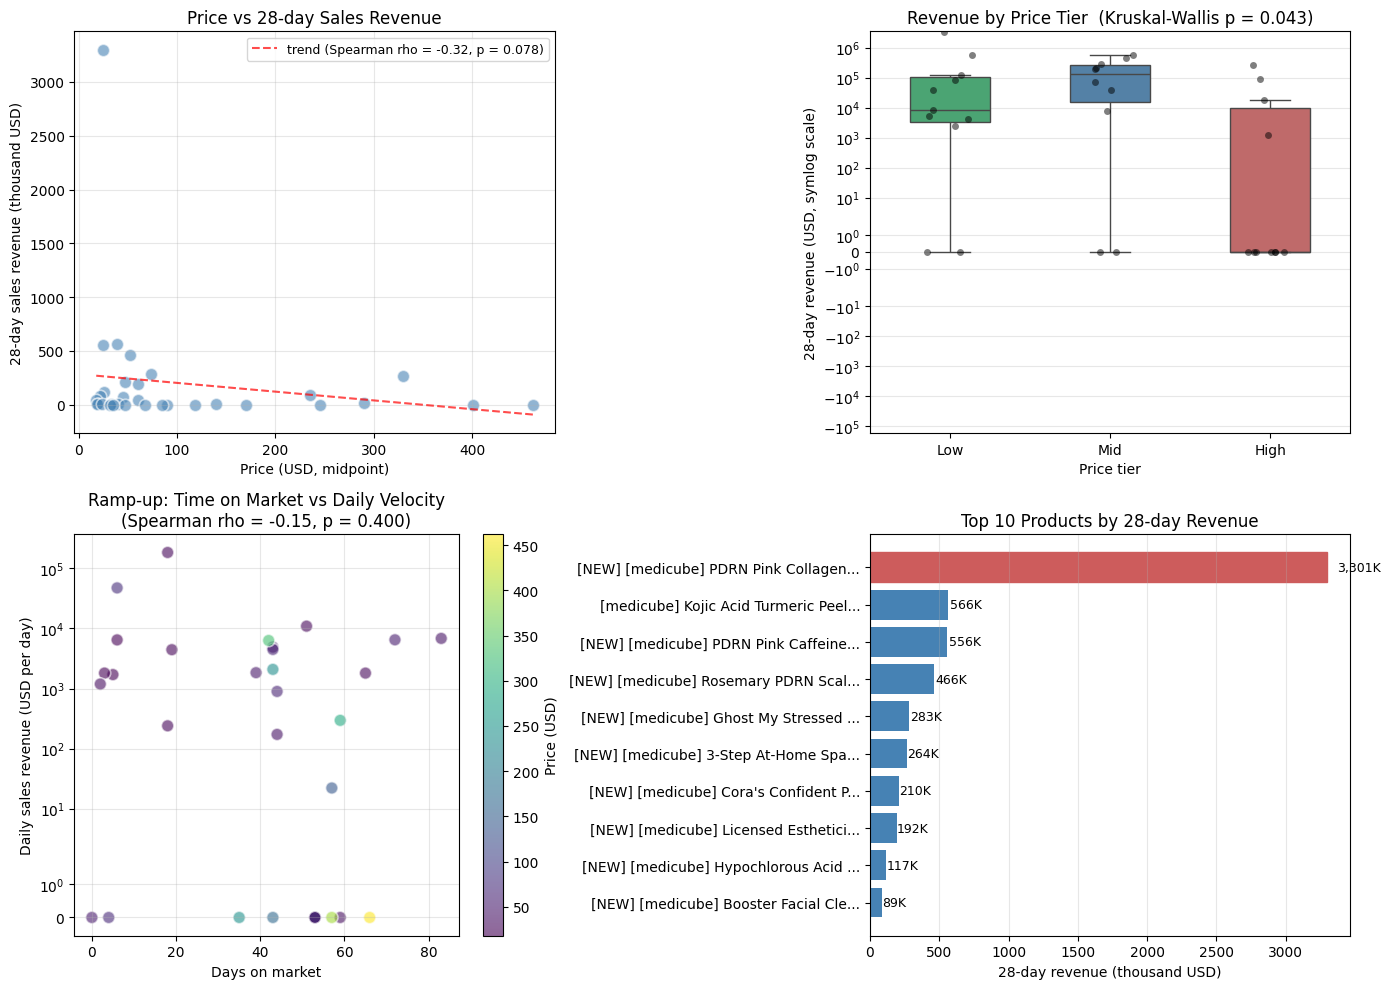

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

# Load
prod = pd.read_csv('/content/drive/MyDrive/DSO 559 Python/fastmoss data/fastmoss data - cleaned/Medicube/medicube_products_cleaned.csv')
print(f"N products: {len(prod)}\n")

# Parse price (handles both '$17.00 - 32.00' and '$52.00')
def parse_price(s):
    """Return midpoint of price range, or single price. NaN if unparseable."""
    if pd.isna(s):
        return np.nan
    nums = re.findall(r'[\d.]+', str(s))
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return np.mean(nums)  # midpoint for ranges, single value for singles

prod['price_usd'] = prod['price'].apply(parse_price)
prod['has_price_range'] = prod['price'].str.contains('-', na=False)

# Parse listing date + compute days on market
prod['listing_date_parsed'] = pd.to_datetime(prod['listing_date'], errors='coerce')
reference_date = prod['listing_date_parsed'].max()
prod['days_on_market'] = (reference_date - prod['listing_date_parsed']).dt.days

print(f"Data snapshot reference date: {reference_date.date()}")
print(f"Days on market range: {prod['days_on_market'].min()}-{prod['days_on_market'].max()} days\n")

# Derived metrics
prod['daily_sales_volume'] = prod['sales_volume_28d'] / np.maximum(prod['days_on_market'], 1)
prod['daily_sales_revenue'] = prod['sales_revenue_28d'] / np.maximum(prod['days_on_market'], 1)

# Descriptive overview
print("=" * 70)
print("Descriptive Overview")
print("=" * 70)
summary = prod[['price_usd', 'days_on_market', 'sales_volume_28d',
                'sales_revenue_28d', 'daily_sales_revenue']].describe().round(2)
print(summary)
print()

zero_sales = (prod['sales_revenue_28d'] == 0).sum()
print(f"Products with zero sales (28d): {zero_sales} / {len(prod)} "
      f"({100*zero_sales/len(prod):.0f}%)")
top_pct = prod['sales_revenue_28d'].max() / prod['sales_revenue_28d'].sum() * 100
print(f"Top product's share of total revenue: {top_pct:.1f}%")
print()

# Price bin analysis
# NOTE: labels avoid '$' because matplotlib treats $ as LaTeX math delimiters.
prod['price_bin'] = pd.qcut(prod['price_usd'], q=3, labels=['Low', 'Mid', 'High'])

print("=" * 70)
print("Sales by Price Tier (tertile bins)")
print("=" * 70)
price_stats = prod.groupby('price_bin', observed=True).agg(
    n=('price_usd', 'count'),
    price_range=('price_usd', lambda x: f"USD {x.min():.1f} to {x.max():.1f}"),
    mean_revenue=('sales_revenue_28d', 'mean'),
    median_revenue=('sales_revenue_28d', 'median'),
    total_revenue=('sales_revenue_28d', 'sum')
).round(0)
print(price_stats)
print()

# Kruskal-Wallis test (non-parametric)
groups = [prod[prod['price_bin']==b]['sales_revenue_28d'].values
          for b in ['Low', 'Mid', 'High']]
h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis across price tiers:  H = {h_stat:.3f},  p = {p_kw:.4f}")
print("  (p<0.05 = price tiers differ in sales revenue)")
print()

# Correlations
print("=" * 70)
print("Correlations: price vs sales performance")
print("=" * 70)

def report_corr(x, y, label_x, label_y):
    r_s, p_s = stats.spearmanr(x, y, nan_policy='omit')
    r_p, p_p = stats.pearsonr(x, y)
    print(f"\n{label_x}  vs  {label_y}")
    print(f"  Spearman rho = {r_s:+.3f}  (p = {p_s:.4f})")
    print(f"  Pearson  r   = {r_p:+.3f}  (p = {p_p:.4f})")
    return r_s, p_s

r_price_rev, p_price_rev = report_corr(
    prod['price_usd'], prod['sales_revenue_28d'],
    "price", "sales_revenue_28d"
)
r_price_vol, p_price_vol = report_corr(
    prod['price_usd'], prod['sales_volume_28d'],
    "price", "sales_volume_28d"
)
r_price_daily, p_price_daily = report_corr(
    prod['price_usd'], prod['daily_sales_revenue'],
    "price", "daily_sales_revenue"
)
print()

# Ramp-up analysis
print("=" * 70)
print("Ramp-up: does time on market correlate with daily sales velocity?")
print("=" * 70)
r_days_daily, p_days_daily = report_corr(
    prod['days_on_market'], prod['daily_sales_revenue'],
    "days_on_market", "daily_sales_revenue"
)
print()

# Top performers
print("=" * 70)
print("Top 5 Products by 28-day Revenue")
print("=" * 70)
top5 = prod.nlargest(5, 'sales_revenue_28d')[
    ['product_title', 'price_usd', 'days_on_market',
     'sales_volume_28d', 'sales_revenue_28d', 'daily_sales_revenue']
].copy()
top5['product_title'] = top5['product_title'].str[:60] + '...'
top5 = top5.round(1)
print(top5.to_string(index=False))
print()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

palette_bins = ['mediumseagreen', 'steelblue', 'indianred']

# (a) Price vs revenue scatter
ax = axes[0, 0]
ax.scatter(prod['price_usd'], prod['sales_revenue_28d'] / 1000,
           s=80, alpha=0.6, color='steelblue', edgecolors='white', linewidth=1.2)
z = np.polyfit(prod['price_usd'], prod['sales_revenue_28d']/1000, 1)
x_line = np.linspace(prod['price_usd'].min(), prod['price_usd'].max(), 100)
ax.plot(x_line, z[0]*x_line + z[1], 'r--', alpha=0.7, linewidth=1.5,
        label=f'trend (Spearman rho = {r_price_rev:+.2f}, p = {p_price_rev:.3f})')
ax.set_xlabel('Price (USD, midpoint)')
ax.set_ylabel('28-day sales revenue (thousand USD)')
ax.set_title('Price vs 28-day Sales Revenue')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

# (b) Revenue by price tier (box + strip)
ax = axes[0, 1]
sns.boxplot(data=prod, x='price_bin', y='sales_revenue_28d',
            ax=ax, palette=palette_bins, showfliers=False, width=0.5)
sns.stripplot(data=prod, x='price_bin', y='sales_revenue_28d',
              ax=ax, color='black', alpha=0.5, size=5, jitter=0.15)
ax.set_yscale('symlog')
ax.set_xlabel('Price tier')
ax.set_ylabel('28-day revenue (USD, symlog scale)')
ax.set_title(f'Revenue by Price Tier  (Kruskal-Wallis p = {p_kw:.3f})')
ax.grid(axis='y', alpha=0.3)

# (c) Days on market vs daily sales velocity
ax = axes[1, 0]
scatter = ax.scatter(prod['days_on_market'], prod['daily_sales_revenue'],
                     s=80, alpha=0.6, c=prod['price_usd'], cmap='viridis',
                     edgecolors='white', linewidth=1.2)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Price (USD)', fontsize=10)
ax.set_xlabel('Days on market')
ax.set_ylabel('Daily sales revenue (USD per day)')
ax.set_yscale('symlog')
ax.set_title(f'Ramp-up: Time on Market vs Daily Velocity\n'
             f'(Spearman rho = {r_days_daily:+.2f}, p = {p_days_daily:.3f})')
ax.grid(alpha=0.3)

# (d) Top 10 products by revenue
ax = axes[1, 1]
top10 = prod.nlargest(10, 'sales_revenue_28d').sort_values('sales_revenue_28d')
labels = [t[:35] + '...' if len(t) > 35 else t
          for t in top10['product_title']]
bars = ax.barh(labels, top10['sales_revenue_28d']/1000, color='steelblue')
bars[-1].set_color('indianred')  # highlight #1
ax.set_xlabel('28-day revenue (thousand USD)')
ax.set_title('Top 10 Products by 28-day Revenue')
for bar, val in zip(bars, top10['sales_revenue_28d']/1000):
    ax.text(val * 1.02, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}K', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()

out_path = os.path.abspath('product_performance.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"Figure saved to: {out_path}")
plt.show()